In [4]:
  # Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Load Dataset
data = pd.read_csv("instagram_data.csv", sep=None, engine="python")

# Clean Column Names
data.columns = data.columns.str.strip()

# Display First Few Rows
data.head()

,followers,post_type,caption_length,hashtag_count,posting_hour,day_of_week,prev_avg_engagement,engagement
0,5000,1,120,10,18,5,300,820
1,2000,0,80,5,12,3,150,300
2,8000,1,150,12,20,6,500,1200
3,3000,0,60,4,10,2,200,350
4,10000,1,200,15,19,7,700,1500


In [6]:
# MATRIX REPRESENTATION

# Feature Matrix A
A = data[['followers','post_type','caption_length',
          'hashtag_count','posting_hour',
          'day_of_week','prev_avg_engagement']].values

# Target Vector B (Actual Engagement)
b = data['engagement'].values

# Add Bias Column (For Base Engagement)
ones = np.ones((A.shape[0], 1))
A = np.hstack((ones, A))

print("Shape of A:", A.shape)
print("Shape of b:", b.shape)

Shape of A: (58, 8)
Shape of b: (58,)


In [7]:
# MATRIX SIMPLIFICATION (RREF)

from sympy import Matrix

# Convert A to sympy matrix
A_sym = Matrix(A)

# Compute RREF
A_rref, pivots = A_sym.rref()

print("RREF of A:")
print(A_rref)

print("\nPivot columns:", pivots)

RREF of A:
Matrix([[1, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0, 0], [0, 0, 1, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, 1, 0], [0, 0, 0, 0, 0, 0, 0, 1], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 

In [8]:
# MATRIX RANK ANALYSIS

rank = np.linalg.matrix_rank(A)

print("Rank of matrix A:", rank)
print("Number of columns in A:", A.shape[1])

Rank of matrix A: 8
Number of columns in A: 8


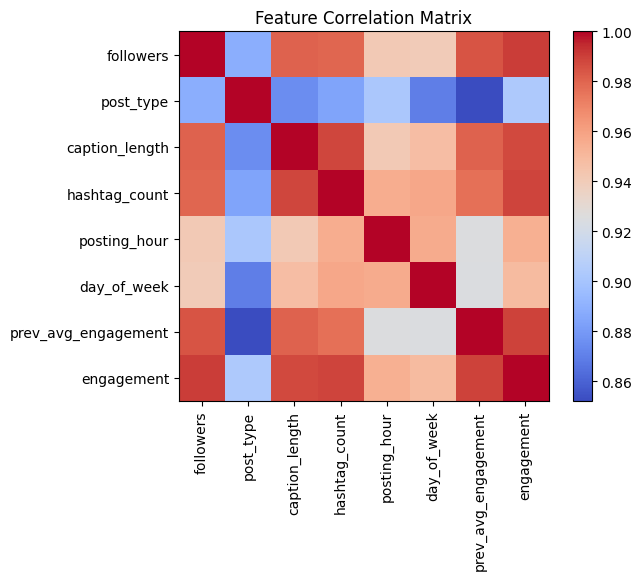

In [9]:
# CORRELATION ANALYSIS

corr = data.corr()

plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.title("Feature Correlation Matrix")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

In [10]:
# ORTHOGONALIZATION (GRAM-SCHMIDT)

def gram_schmidt(A):
    Q = []

    for i in range(A.shape[1]):
        v = A[:, i]

        for q in Q:
            v = v - np.dot(q, A[:, i]) * q

        norm = np.linalg.norm(v)
        if norm > 1e-10:
            Q.append(v / norm)

    return np.array(Q).T

# Apply Gram-Schmidt
Q = gram_schmidt(A[:, 1:])  # Exclude Bias

print("Orthogonality check (Q^T Q):\n", Q.T @ Q)
print("Shape of orthogonal basis Q:", Q.shape)

Orthogonality check (Q^T Q):
 [[ 1.00000000e+00  4.18421289e-17 -6.78094940e-16 -3.25276300e-15
  -2.72976915e-15  2.33386862e-15  3.40620029e-15]
 [ 4.18421289e-17  1.00000000e+00 -6.60427629e-16 -1.81446657e-16
   4.83339060e-16 -5.69274810e-16 -3.56503254e-16]
 [-6.78094940e-16 -6.60427629e-16  1.00000000e+00  7.26921370e-15
   7.72886983e-15 -1.58258209e-16  8.86493413e-15]
 [-3.25276300e-15 -1.81446657e-16  7.26921370e-15  1.00000000e+00
   1.63641933e-14  1.44119082e-14  5.80851216e-14]
 [-2.72976915e-15  4.83339060e-16  7.72886983e-15  1.63641933e-14
   1.00000000e+00  1.87895881e-14  3.28083718e-14]
 [ 2.33386862e-15 -5.69274810e-16 -1.58258209e-16  1.44119082e-14
   1.87895881e-14  1.00000000e+00 -3.51183705e-14]
 [ 3.40620029e-15 -3.56503254e-16  8.86493413e-15  5.80851216e-14
   3.28083718e-14 -3.51183705e-14  1.00000000e+00]]
Shape of orthogonal basis Q: (58, 7)


In [11]:
# LEAST SQUARES SOLUTION

# Compute Weights Using Pseudo-Inverse
x = np.linalg.pinv(A) @ b

print("Weights:\n", x)

Weights:
 [-8.95866001e+01  1.64462499e-02  1.22652824e+02  6.58705363e-01
  1.64231811e+01  5.81309736e+00  5.84259525e+00  1.10104719e+00]


In [12]:
# FEATURE INTERPRETATION

features = ["bias","followers","post_type","caption_length",
            "hashtag_count","posting_hour",
            "day_of_week","prev_avg_engagement"]

# Ignore bias
weights = x[1:]
feature_names = features[1:]

# Sort by absolute importance
sorted_features = sorted(zip(feature_names, weights), key=lambda x: abs(x[1]), reverse=True)

print("Feature Importance (sorted):\n")

for f, w in sorted_features:
    print(f"{f}: {w:.2f}")

Feature Importance (sorted):

post_type: 122.65
hashtag_count: 16.42
day_of_week: 5.84
posting_hour: 5.81
prev_avg_engagement: 1.10
caption_length: 0.66
followers: 0.02


In [13]:
# PROJECTION (Ax ≈ b)

# Predicted Engagement
b_pred = A @ x

print("First 5 actual values:", b[:5])
print("First 5 predicted values:", b_pred[:5])

First 5 actual values: [ 820  300 1200  350 1500]
First 5 predicted values: [ 822.73681263  330.56026618 1162.36131257  354.99279705 1497.69755892]


In [14]:
# ERROR CALCULATION

# Mean Squared Error
error = np.mean((b - b_pred)**2)

print("Mean Squared Error:", error)

Mean Squared Error: 747.731257728166


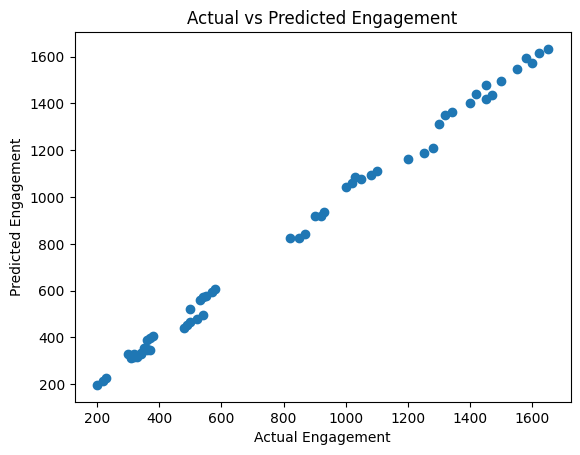

In [15]:
# ACTUAL vs PREDICTED GRAPH

plt.scatter(b, b_pred)
plt.xlabel("Actual Engagement")
plt.ylabel("Predicted Engagement")
plt.title("Actual vs Predicted Engagement")
plt.show()

In [16]:
# PREDICT NEW POST

def predict(new_post, weights):
    new_post = np.array([1] + new_post)  # add bias
    return new_post @ weights

# Example New Post
sample = [6000, 1, 120, 8, 19, 6, 400]

print("Predicted Engagement:", predict(sample, x))

Predicted Engagement: 928.0971115617479


In [17]:
# EIGENVALUE ANALYSIS

# Covariance Matrix
cov_matrix = np.cov(A.T)

# Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:\n", eigenvalues)

Eigenvalues:
 [7.54832996e+06 1.27396180e+03 7.38793302e+01 2.04492968e+00
 3.67327686e-01 1.82243058e-01 3.89236664e-02 0.00000000e+00]
